### SDSS Galaxies vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 

#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [179]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, precision_recall_curve,  accuracy_score
from astroML.utils import completeness_contamination
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from astroML.classification import GMMBayes

In [49]:
data = pd.read_csv("galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [50]:
u_g = (data['u'] - data['g']).to_numpy()
g_r = (data['g'] - data['r']).to_numpy()
r_i = (data['r'] - data['i']).to_numpy()
i_z = (data['i'] - data['z']).to_numpy()
labels = data['class'].map({'GALAXY': 0, 'QSO': 1}).to_numpy()

X = np.column_stack([u_g, g_r, r_i, i_z])
y = labels

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, test_size=0.25, random_state=42)

Let's try different classification methods and look at their ROC curves. For KNeighborsClassifier and GMMBayes I will first find their best parameters through cross validation.

In [77]:
def classifier_model (X_train, y_train, X_test, *args):
    names = []
    probs = []
    for classifier, kwargs in args:
        clf = classifier(**kwargs)
        clf.fit(X_train, y_train)
        y_prob = clf.predict_proba(X_test)[:, 1]
        probs.append(y_prob)
        names.append(classifier.__name__)
    return names, probs

# I cannot use GridSearchCV because GMMBayes is not compatible with sklearn
best_score = -np.inf
best_n = None
n_range = np.arange(1, 10)
for n in n_range:
    clf = GMMBayes(n_components=n)
    y_pred = cross_val_predict(clf, X_train, y_train)
    score = accuracy_score(y_train, y_pred)
    if score > best_score:
        best_score = score
        best_n = n
n_opt = best_n

best_score = -np.inf
best_k = None
k_range = np.arange(1, 20)
for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)
    y_pred = cross_val_predict(clf, X_train, y_train)
    score = accuracy_score(y_train, y_pred)
    if score > best_score:
        best_score = score
        best_k = k
k_opt = best_k

print(f"Optimal n_components for GMMBayes: {n_opt}")
print(f"Optimal n_neighbors for KNeighborsClassifier: {k_opt}")

names, probs = classifier_model(X_train, y_train, X_test,
                                (GaussianNB, {}),
                                (QDA, {}),
                                (KNeighborsClassifier, {'n_neighbors': k_opt}),
                                (GMMBayes, {'n_components': n_opt}))

Optimal n_components for GMMBayes: 7
Optimal n_neighbors for KNeighborsClassifier: 9


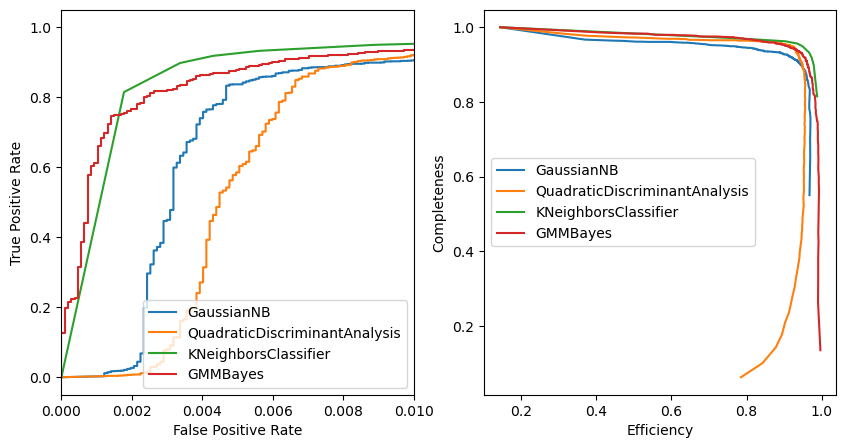

In [79]:
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

tresholds = np.linspace(0, 1, 1001) [:-1]

for name, y_prob in zip(names, probs):
    fpr, tpr, tresh = roc_curve(y_test, y_prob)
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])

    ax1.plot(fpr, tpr, label=name)

    precision, recall, tresh2 = precision_recall_curve(y_test, y_prob)
    precision = np.concatenate([[0], precision])
    recall = np.concatenate([[1], recall])
    tresh2 = np.concatenate([[0], tresh2])

    comp = np.zeros_like(tresholds)
    cont = np.zeros_like(tresholds)
    for i, t in enumerate(tresholds):
        y_pred = (y_prob >= t)
        comp[i], cont[i] = completeness_contamination(y_pred, y_test)
    
    ax2.plot(1-cont, comp, label=name)

ax1.set_xlim(0, 0.01)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

ax2.set_xlabel('Efficiency')
ax2.set_ylabel('Completeness')
ax2.legend()

We can see that the best performance is obtained by the KNeighborsClassifier, reaching the highest True Positive Rate with a low False Positive Rate, while the worst performance is the one of the QuadraticDiscriminatAnalysis.

Let's now see what happens if i take different subsets of colors. Let's star by using just one color:

Best color: u-g


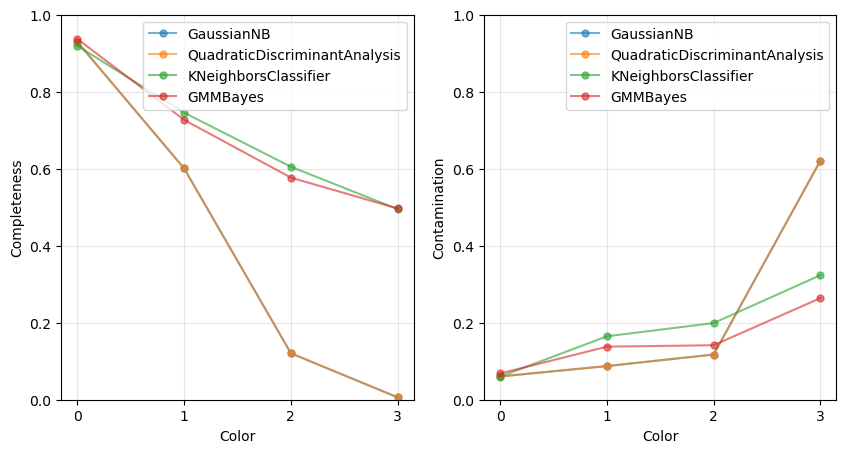

In [173]:
def classifier_model_1color(colors,*args):
    names = []
    predictions = []
    for classifier, kwargs in args:
        classifiers.append([])
        predictions.append([])
        for i in range(len(colors)):
            clf = classifier(**kwargs)
            clf.fit(X_train[:,i][:,np.newaxis], y_train)
            y_pred = clf.predict(X_test[:,i][:,np.newaxis])
            predictions[-1].append(y_pred)
        names.append(classifier.__name__)
    return names, predictions

colors = np.arange(4)

names, predictions = classifier_model_1color(colors,
                                (GaussianNB, {}),
                                (QDA, {}),
                                (KNeighborsClassifier, {'n_neighbors': k_opt}),
                                (GMMBayes, {'n_components': n_opt}))

completeness, contamination = completeness_contamination(predictions, y_test)

fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

for comp, cont, name in zip(completeness, contamination, names):
    ax1.plot(range(len(colors)), comp, '-o', ms=5, alpha=0.6, label=name)
    ax2.plot(range(len(colors)), cont, '-o', ms=5, alpha=0.6, label=name)

ax1.xaxis.set_major_locator(plt.MultipleLocator(1))
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax1.set_xlabel('Color')
ax1.set_ylabel('Completeness')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
ax1.legend()

ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax2.set_xlabel('Color')
ax2.set_ylabel('Contamination')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)
ax2.legend()

color_names = ['u-g','g-r','r-i','i-z']
print('Best color:', color_names[np.argmin(contamination[3])]) # GMMBayes

It seems that the most important features for classifing our object is the first color $(u-g)$ since it has the highest completeness and lowest contamination.

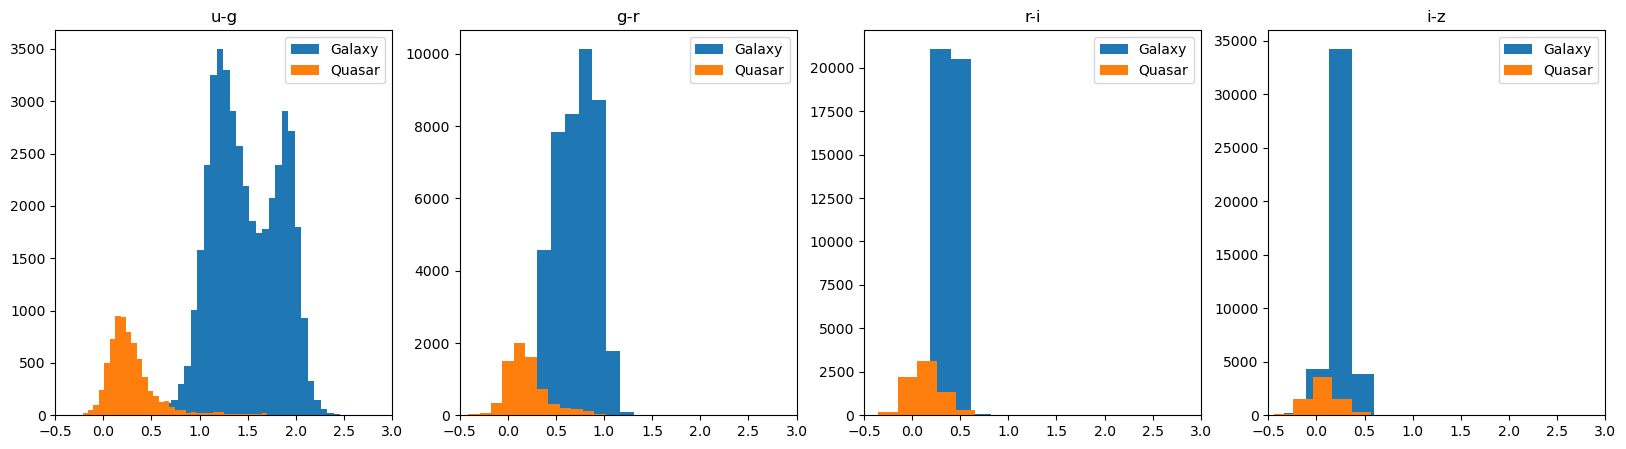

In [187]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for i in range (4): 
    ax[i].hist(X[:, i][y==0], bins=100, label='Galaxy')
    ax[i].hist(X[:, i][y==1], bins=100, label='Quasar')
    ax[i].legend()
    ax[i].set_xlim(-0.5,3)
    ax[i].set_title(color_names[i])

Indeed, if we look at their distribution, the $(u-g)$ color is the one where the separation between the two classes is more visible, even by eye.

Let's now try with two colors: 

[('u-g', 'g-r'), ('u-g', 'r-i'), ('u-g', 'i-z'), ('g-r', 'r-i'), ('g-r', 'i-z'), ('r-i', 'i-z')]
Best pair: ('u-g', 'i-z')


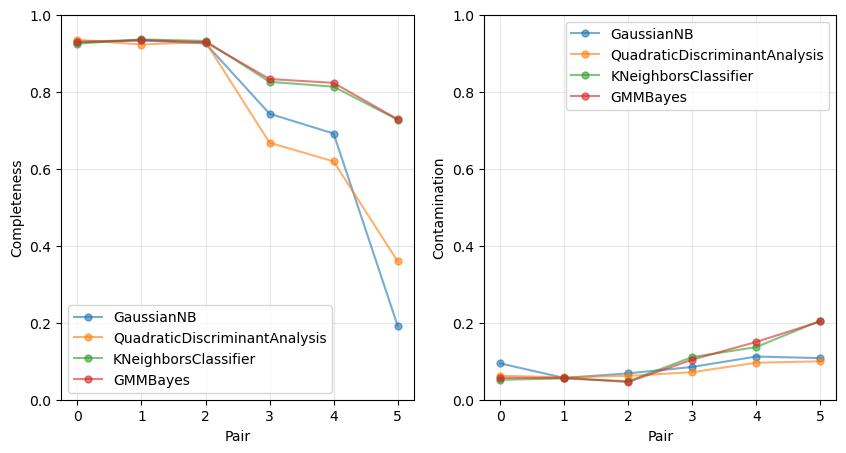

In [174]:
from itertools import combinations

colors = np.arange(4)
pairs = list(combinations(colors, 2))

pair_names = [(color_names[i], color_names[j]) for i,j in pairs ]
print(pair_names)

def classifier_model_2colors(pairs, *args):
    names = []
    predictions = []
    for classifier, kwargs in args:
        classifiers.append([])
        predictions.append([])
        for pair in pairs:
            clf = classifier(**kwargs)
            clf.fit(X_train[:,pair], y_train)
            y_pred = clf.predict(X_test[:,pair])
            predictions[-1].append(y_pred)
        names.append(classifier.__name__)
    return names, predictions

names, predictions = classifier_model_2colors(pairs,
                                (GaussianNB, {}),
                                (QDA, {}),
                                (KNeighborsClassifier, {'n_neighbors': k_opt}),
                                (GMMBayes, {'n_components': n_opt}))

completeness, contamination = completeness_contamination(predictions, y_test)

fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

for comp, cont, name in zip(completeness, contamination, names):
    ax1.plot(range(len(pairs)), comp, '-o', ms=5, alpha=0.6, label=name)
    ax2.plot(range(len(pairs)), cont, '-o', ms=5, alpha=0.6, label=name)

ax1.xaxis.set_major_locator(plt.MultipleLocator(1))
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax1.set_xlabel('Pair')
ax1.set_ylabel('Completeness')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
ax1.legend()

ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax2.set_xlabel('Pair')
ax2.set_ylabel('Contamination')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)
ax2.legend()

print('Best pair:', pair_names[np.argmin(contamination[3])]) # GMMBayes

The most informative pair is $(u-g, i-z)$.

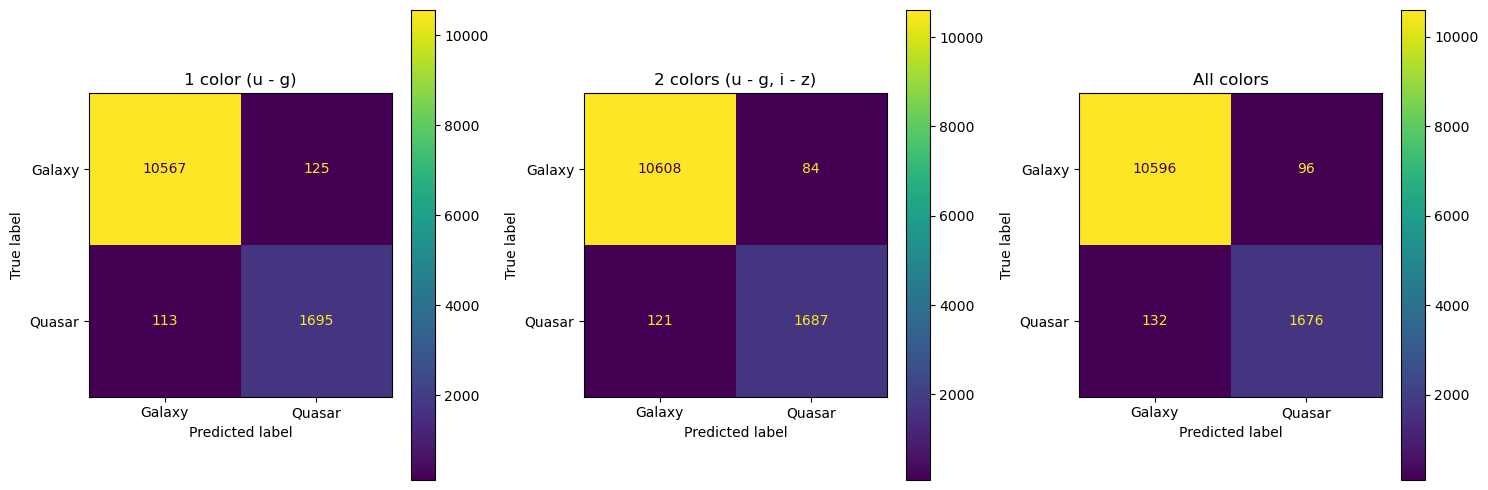

In [200]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title('1 color (u - g)')
ax[1].set_title('2 colors (u - g, i - z)')
ax[2].set_title('All colors')


clf = GMMBayes(n_components=n_opt)
clf.fit(X_train[:,0].reshape(-1, 1), y_train)
y_pred_1 = clf.predict(X_test[:,0].reshape(-1, 1))
conf_matrix_1 = confusion_matrix(y_test, y_pred_1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_1, display_labels=['Galaxy', 'Quasar'])
disp1.plot(ax=ax[0])

clf = GMMBayes(n_components=n_opt)
clf.fit(X_train[:,[0,3]], y_train)
y_pred_2 = clf.predict(X_test[:,[0,3]])
conf_matrix_2 = confusion_matrix(y_test, y_pred_2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_2, display_labels=['Galaxy', 'Quasar'])
disp2.plot(ax=ax[1])

clf = GMMBayes(n_components=n_opt)
clf.fit(X_train, y_train)
y_pred_all = clf.predict(X_test)
conf_matrix_all = confusion_matrix(y_test, y_pred_all)
disp_all = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_all, display_labels=['Galaxy', 'Quasar'])
disp_all.plot( ax=ax[2])

plt.tight_layout()

In [204]:
completeness_1, contamination_1 = completeness_contamination(y_pred_1, y_test)
completeness_2, contamination_2 = completeness_contamination(y_pred_2, y_test)
completeness_all, contamination_all = completeness_contamination(y_pred_all, y_test)

print(f"1 color:     Completeness = {completeness_1:.4f}  Contamination = {contamination_1:.4f}")
print(f"2 colors:    Completeness = {completeness_2:.4f}  Contamination = {contamination_2:.4f}")
print(f"All colors:  Completeness = {completeness_all:.4f}  Contamination = {contamination_all:.4f}")


1 color:     Completeness = 0.9375  Contamination = 0.0687
2 colors:    Completeness = 0.9331  Contamination = 0.0474
All colors:  Completeness = 0.9270  Contamination = 0.0542


We can see that uing just 1 color gives slightly higher completeness but more contamination, while the 2 color combination slightly lowers completeness but reduces contamination, making it a better balance overall.